# Bivariate Panel SVAR: Basket Return -> Liquidation

**Identification**: Short-run (Cholesky) restriction, flipped ordering from `bivariate_liq_return`.

**Variables (ordered)**:
1. `basket_return` - per-CSU daily log return of collateral basket, I(0).
2. `liquidation` - per-CSU daily $\log(1 + \text{USD liquidation})$, I(0).

**Shocks**:
1. `return_shock` - exogenous price innovation; **can move liquidation contemporaneously** (price-triggering channel).
2. `liquidation_shock` - autonomous liquidation activity; has **zero contemporaneous effect on return** (the forced-sale contemporaneous channel is attributed to return_shock under this ordering).

**Restriction**: $A(0)_{1,2} = 0$. Under this ordering, the identified `return_shock` captures exogenous crypto-market price moves. The IRF of liquidation to return_shock at h=0 measures how much autonomous liquidation activity is mechanically triggered by the same-day price move - the price-triggering channel that the health-factor microfoundation predicts should scale with HF variance.

**Why this ordering for the HF second-stage.** The health-factor variance $\sigma_C^2 + \sigma_D^2 - 2\,\text{Cov}$ predicts the sensitivity of liquidations to price moves ($r \to \text{liq}$), not the price impact of forced sales ($\text{liq} \to r$). The prior notebook (`bivariate_liq_return`) identified the latter. This notebook identifies the former, which is what HF_Var should predict cross-sectionally.

**Sample**: `panel_svar_data_qualified.parquet`, 2024-07-24 to 2025-12-31, CSUs with $\ge 50$ liq days.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
try:
    _nb_dir = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    _nb_dir = Path.cwd()
sys.path.insert(0, str(_nb_dir))
import svar_nb
PROJECT_ROOT, OUTPUT_DIR = svar_nb.setup(
    'results/pedroni/bivariate_return_liq',
    notebook_dir=_nb_dir,
)

svar_nb loaded.
Project root : /Users/lewisschrock/Desktop/Academics/thesis_v2.10
Output dir   : /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq


In [2]:
# ─────────────────────────────────────────────────────────────────────
# USER-EDITABLE PLOTTING CONTROLS
# ─────────────────────────────────────────────────────────────────────
PLOT_STEPS   = 5
SHOW_MEMBERS = False
IRF_TYPES    = ['common', 'idiosyncratic']

MAXLAGS      = 30
NSTEPS       = 30
MIN_LIQ_DAYS = 15

# ─────────────────────────────────────────────────────────────────────
# VAR SPECIFICATION — ordering (basket_return, liquidation)
# Restriction: liquidation_shock has zero contemporaneous effect on basket_return.
# Identifies the PRICE-TRIGGERING channel (return_shock -> liquidation at h=0 allowed).
# ─────────────────────────────────────────────────────────────────────
VARIABLE_ORDER = ['basket_return', 'liquidation']
VARIABLES = {
    'basket_return': [0, 0],
    'liquidation':   [0, 0],
}
SHOCKS = ['return_shock', 'liquidation_shock']

SR_CONSTRAINT = np.array([
    ['.', '0'],
    ['.', '.'],
])
SR_SIGN = np.array([
    ['+', '.'],
    ['.', '+'],
])
LR_CONSTRAINT = np.array([])
LR_SIGN       = np.array([])

# ─────────────────────────────────────────────────────────────────────
# Shock normalizations (both applied to the plotted IRFs)
#   return_shock        : scaled so h=0 basket_return response = -1%   (a 1% crypto decline)
#   liquidation_shock   : scaled so h=0 liquidation   response = +1 log-point
# ─────────────────────────────────────────────────────────────────────
NORM_RETURN_SHOCK_IDX = 0
NORM_RETURN_VAR_IDX   = 0
NORM_RETURN_HORIZON   = 0
NORM_RETURN_TARGET    = -0.01

NORM_LIQ_SHOCK_IDX    = 1
NORM_LIQ_VAR_IDX      = 1
NORM_LIQ_HORIZON      = 0
NORM_LIQ_TARGET       = 0.01


In [3]:
df, eligible, sigmas = svar_nb.load_panel(
    PROJECT_ROOT,
    variable_order=VARIABLE_ORDER,
    variables_dict=VARIABLES,
    min_liq_days=MIN_LIQ_DAYS,
)


Panel: 42 CSUs total, 38 eligible (>= 15 liq days), 20,467 obs
  sigma_basket_return: median=0.0244
  sigma_liquidation: median=3.2258


In [4]:
raw_irfs = svar_nb.run_panel(
    'Bivariate Cholesky: basket_return -> liquidation', df, eligible,
    variable_order=VARIABLE_ORDER, variables_dict=VARIABLES, shocks=SHOCKS,
    sr_constraint=SR_CONSTRAINT, lr_constraint=LR_CONSTRAINT,
    sr_sign=SR_SIGN, lr_sign=LR_SIGN, maxlags=MAXLAGS, nsteps=NSTEPS,
)


Bivariate Cholesky: basket_return -> liquidation  (N=38 CSUs, 18,469 obs)
Transformation matrix M:
[[ 0.9062568   0.        ]
 [-0.17769025  0.41823834]] 

Transformation matrix M:
[[ 0.98393502  0.        ]
 [-0.09412593  0.8441387 ]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Transformation matrix M:
[[ 0.97753553  0.        ]
 [-0.22797283  0.9062705 ]] 

Transformation matrix M:
[[ 0.9978573   0.        ]
 [-0.19981576  0.92940403]] 

Transformation matrix M:
[[ 0.98629409  0.        ]
 [-0.10224312  0.95970646]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Transformation matrix M:
[[ 0.97557971  0.        ]
 [-0.14296006  0.88787717]] 

No lags selected for  aave_v3_celo .
Transformation matrix M:
[[ 0.98393107  0.        ]
 [-0.24374983  0.86756772]] 



...

Transformation matrix M:
[[ 0.86430578  0.        ]
 [-0.11382267  0.79478945]] 

Transformation matrix M:
[[ 0.99772136  0.        ]
 [-0.09374326  0.90415906]] 

Transformation matrix M:
[[ 0.97067467  0.        ]
 [-0.14430994  0.86982202]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Transformation matrix M:
[[ 0.9955701   0.        ]
 [-0.16547452  0.89186924]] 

Transformation matrix M:
[[ 0.99342702  0.        ]
 [-0.12484682  0.9417318 ]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Converged: 36 / 38


In [5]:
# ─────────────────────────────────────────────────────────────────────
# Two parallel sets of IRFs:
#   irfs         — normalized to a ±1% reference event in each variable's
#                  own scale (return_shock = -1%, liq_shock = +0.01 log-pt)
#   irfs_sigma   — 1-standard-deviation shocks: undo z-score only, no further
#                  rescaling.  At h=0, each shock's own-variable response
#                  equals that CSU's empirical sigma of the residual.
# Both share the same identification; they differ only in shock scale.
# ─────────────────────────────────────────────────────────────────────

# ---------- 1-sigma version ----------
irfs_sigma = svar_nb.undo_zscore(raw_irfs, sigmas, VARIABLE_ORDER)

# ---------- ±1% reference-event version ----------
irfs = svar_nb.undo_zscore(raw_irfs, sigmas, VARIABLE_ORDER)
irfs, scales_ret = svar_nb.normalize_shock_per_type(
    irfs, shock_idx=NORM_RETURN_SHOCK_IDX, var_idx=NORM_RETURN_VAR_IDX,
    target=NORM_RETURN_TARGET, horizon=NORM_RETURN_HORIZON,
)
irfs, scales_liq = svar_nb.normalize_shock_per_type(
    irfs, shock_idx=NORM_LIQ_SHOCK_IDX, var_idx=NORM_LIQ_VAR_IDX,
    target=NORM_LIQ_TARGET, horizon=NORM_LIQ_HORIZON,
)


  Normalize shock 0 [composite]: median h=0 response = +0.02464 → -0.01000  (scale = -0.406x)
  Normalize shock 0 [common]: median h=0 response = +0.02298 → -0.01000  (scale = -0.435x)
  Normalize shock 0 [idiosyncratic]: median h=0 response = +0.00587 → -0.01000  (scale = -1.703x)
  Normalize shock 1 [composite]: median h=0 response = +2.98819 → +0.01000  (scale = +0.003x)
  Normalize shock 1 [common]: median h=0 response = +1.54536 → +0.01000  (scale = +0.006x)
  Normalize shock 1 [idiosyncratic]: median h=0 response = +2.49265 → +0.01000  (scale = +0.004x)


  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/irfs_common.png


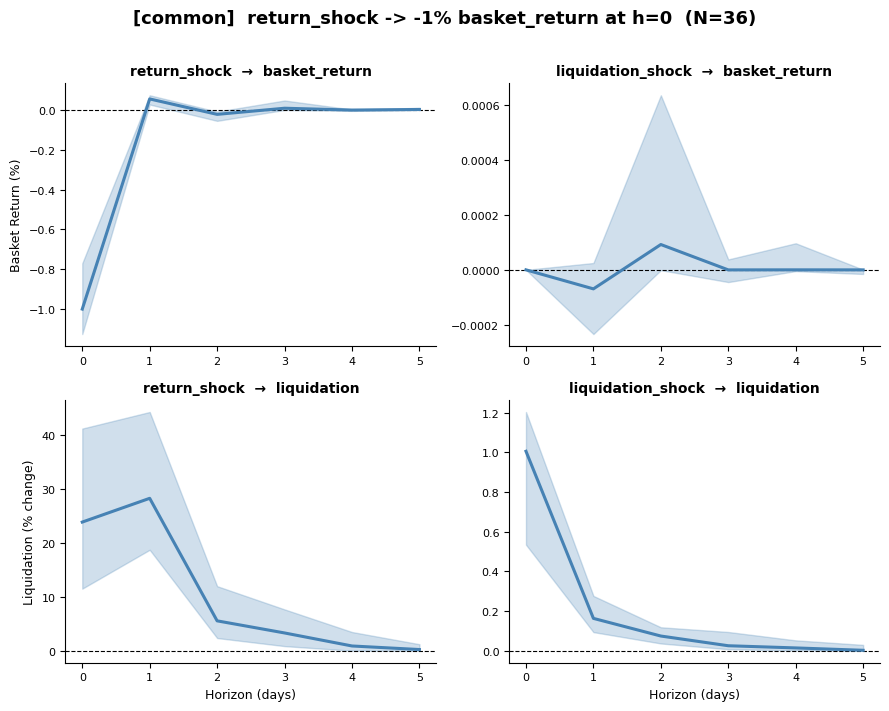

  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/irfs_idiosyncratic.png


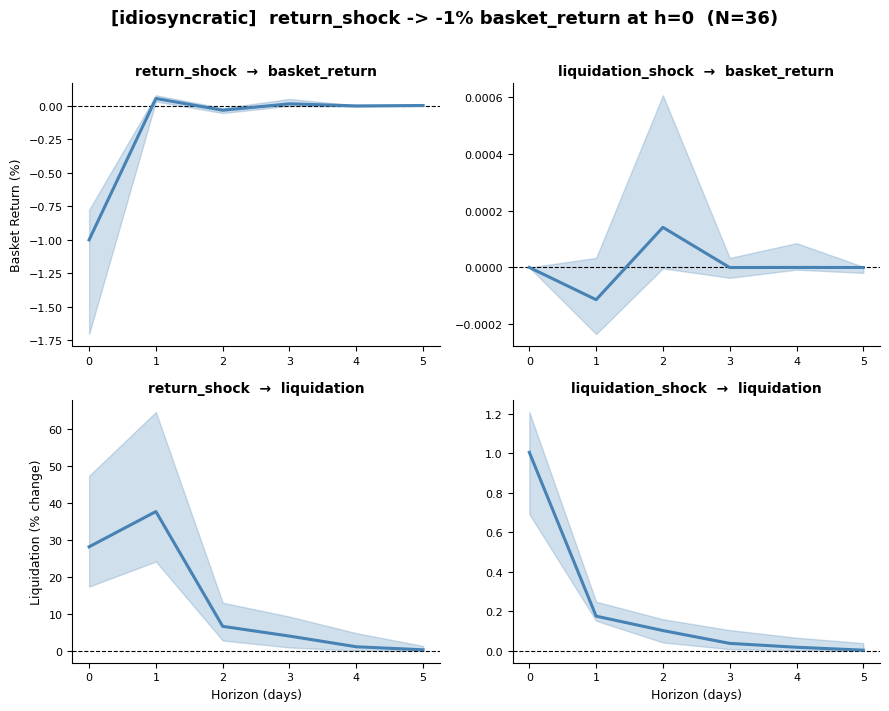

  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/irfs_common_1sigma.png


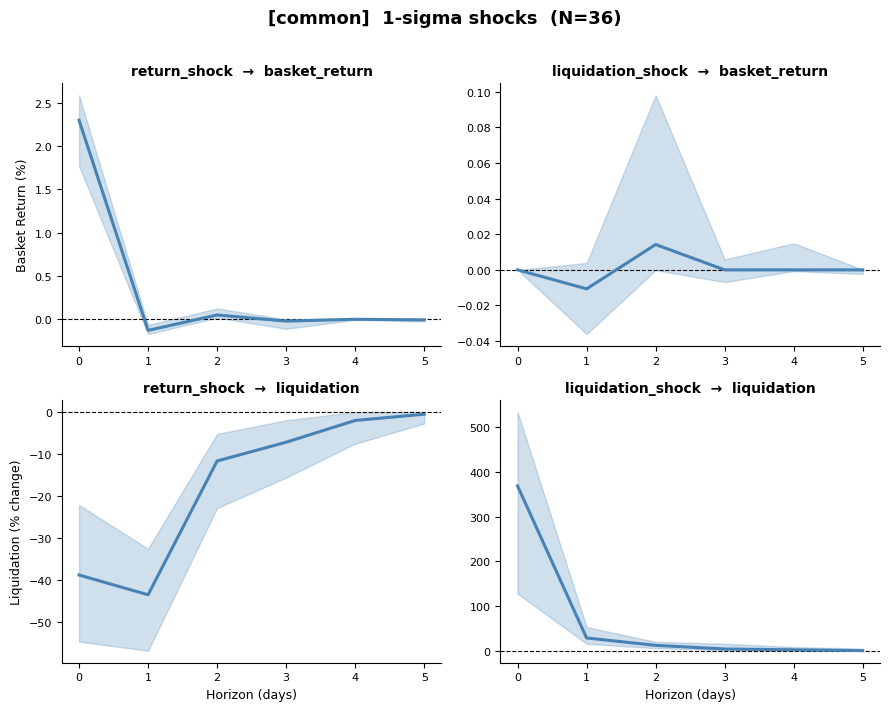

  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/irfs_idiosyncratic_1sigma.png


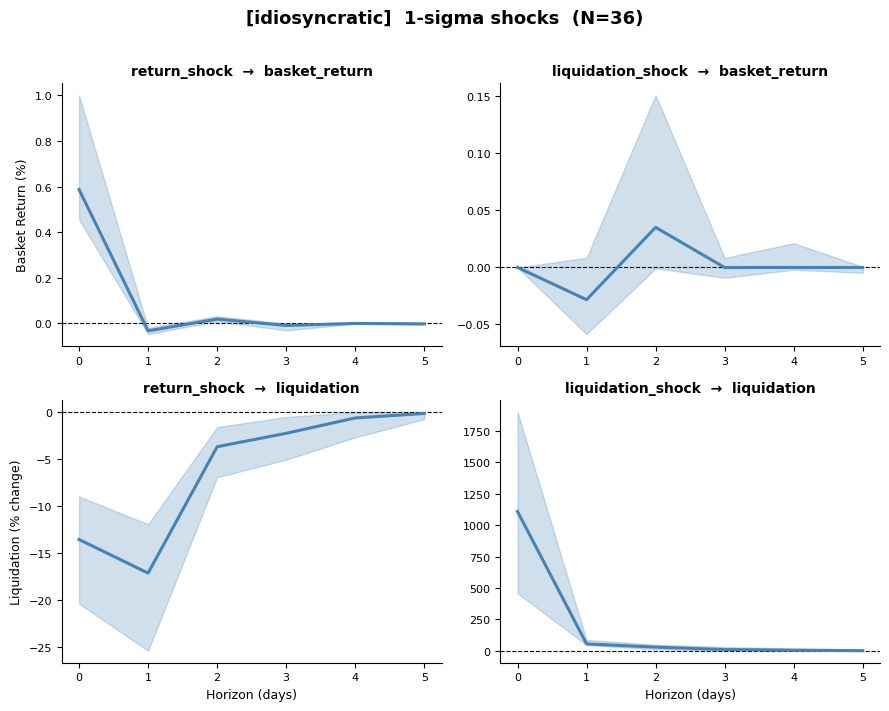

In [6]:
# ─────────────────────────────────────────────────────────────────────
# Plot both variants.  Each writes to a separate file so they can be
# compared side by side.
# ─────────────────────────────────────────────────────────────────────

# Reference-event normalization (return -1%, liq +1% USD volume)
for it in IRF_TYPES:
    svar_nb.plot_irfs_grid(
        irfs, variable_order=VARIABLE_ORDER, shock_names=SHOCKS,
        irf_type=it,
        show_members=SHOW_MEMBERS,
        title=f'[{it}]  return_shock -> -1% basket_return at h=0  (N={len(irfs)})',
        nsteps=PLOT_STEPS,
        save_path=OUTPUT_DIR / f'irfs_{it}.png',
    )

# 1-sigma shocks: each shock at one standard deviation of its residual
for it in IRF_TYPES:
    svar_nb.plot_irfs_grid(
        irfs_sigma, variable_order=VARIABLE_ORDER, shock_names=SHOCKS,
        irf_type=it,
        show_members=SHOW_MEMBERS,
        title=f'[{it}]  1-sigma shocks  (N={len(irfs_sigma)})',
        nsteps=PLOT_STEPS,
        save_path=OUTPUT_DIR / f'irfs_{it}_1sigma.png',
    )


In [7]:
lam_df = svar_nb.lambda_summary(raw_irfs, VARIABLE_ORDER)

                           lambda_basket_return  lambda_liquidation
csu                                                                
aave_v2_polygon                        0.981139            0.446775
aave_v3_arbitrum                       0.985011            0.633049
aave_v3_avalanche                      0.914010            0.578073
aave_v3_base                           0.980169            0.235059
aave_v3_binance                        0.921822            0.539272
aave_v3_ethereum                       0.984432            0.567274
aave_v3_gnosis                         0.957213            0.302715
aave_v3_linea                          0.965485            0.595203
aave_v3_optimism                       0.983002            0.409525
aave_v3_polygon                        0.966176            0.572583
aave_v3_scroll                         0.966890            0.579886
aave_v3_sonic                          0.745175            0.460768
benqi_lending_avalanche                0.895876 

  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/fevd_common.png


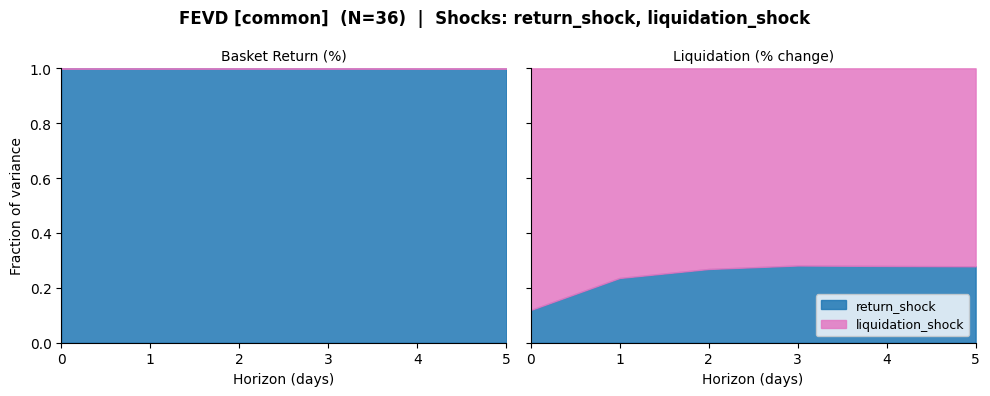

  Saved: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq/fevd_idiosyncratic.png


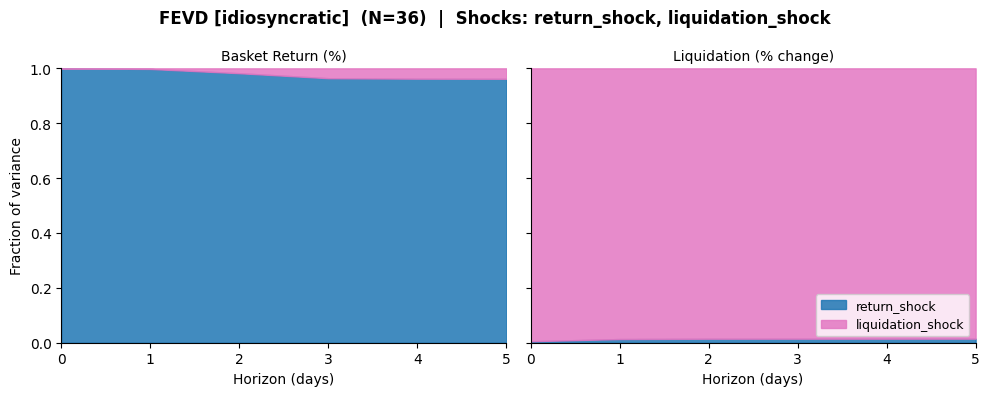

Share of forecast-error variance by shock:

  [common]
    basket_return:
      h=  0:  return_shock = 100.0%   liquidation_shock =   0.0%
      h=  1:  return_shock = 100.0%   liquidation_shock =   0.0%
      h=  5:  return_shock =  99.9%   liquidation_shock =   0.1%
      h= 15:  return_shock =  99.9%   liquidation_shock =   0.1%
      h= 30:  return_shock =  99.9%   liquidation_shock =   0.1%
    liquidation:
      h=  0:  return_shock =  11.9%   liquidation_shock =  88.1%
      h=  1:  return_shock =  23.6%   liquidation_shock =  76.4%
      h=  5:  return_shock =  27.9%   liquidation_shock =  72.1%
      h= 15:  return_shock =  28.4%   liquidation_shock =  71.6%
      h= 30:  return_shock =  28.4%   liquidation_shock =  71.6%

  [idiosyncratic]
    basket_return:
      h=  0:  return_shock = 100.0%   liquidation_shock =   0.0%
      h=  1:  return_shock =  99.8%   liquidation_shock =   0.2%
      h=  5:  return_shock =  96.2%   liquidation_shock =   3.8%
      h= 15:  return_shock

In [8]:
fevd_by_type = {}
for it in IRF_TYPES:
    fevd_by_type[it] = svar_nb.compute_fevd(raw_irfs, irf_type=it)
    svar_nb.plot_fevd_grid(
        fevd_by_type[it], variable_order=VARIABLE_ORDER, shock_names=SHOCKS,
        title=f'FEVD [{it}]  (N={len(raw_irfs)})  |  Shocks: {", ".join(SHOCKS)}',
        nsteps=PLOT_STEPS,
        save_path=OUTPUT_DIR / f'fevd_{it}.png',
    )

print('Share of forecast-error variance by shock:')
for it in IRF_TYPES:
    stacked = np.stack(list(fevd_by_type[it].values()))
    med = np.median(stacked, axis=0)
    print(f'\n  [{it}]')
    for var_idx, var in enumerate(VARIABLE_ORDER):
        print(f'    {var}:')
        for h in [0, 1, 5, 15, 30]:
            s0 = med[h, var_idx, 0] * 100
            s1 = med[h, var_idx, 1] * 100
            print(f'      h={h:3d}:  {SHOCKS[0]} = {s0:5.1f}%   {SHOCKS[1]} = {s1:5.1f}%')

In [9]:
svar_nb.save_results(
    raw_irfs, variable_order=VARIABLE_ORDER, shock_names=SHOCKS,
    output_dir=OUTPUT_DIR,
)

  Saved: irfs_composite.csv
  Saved: irfs_common.csv
  Saved: irfs_idiosyncratic.csv
  Saved: lambda.csv


  Saved: fevd.csv

All results saved to: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/pedroni/bivariate_return_liq


---

# Second-stage cross-sectional tests

Per-CSU outputs from the first-stage SVAR feed cross-sectional OLS regressions of the form $y_i = \alpha + \beta x_i + \varepsilon_i$, with HC3 standard errors. Pedroni-canonical pattern: the dependent variable is a member-specific impulse response, the regressor is a CSU-level observable.

1. **Market depth** — does $\log(\text{TVL}_i)$ predict the per-CSU common-component price-triggering IRF at $h = 1$?
2. **Denomination** — does the stablecoin share of each CSU's debt book predict the same IRF?


In [10]:
import statsmodels.api as sm

lam = pd.read_csv(OUTPUT_DIR / 'lambda.csv')[['csu', 'lam_liquidation_liquidation']] \
        .rename(columns={'lam_liquidation_liquidation': 'lam_liq'})

def _load_irf(kind):
    df = pd.read_csv(OUTPUT_DIR / f'irfs_{kind}.csv')
    return df[(df['variable']=='liquidation') & (df['shock']=='return_shock')].copy()

irf_comp = _load_irf('composite')
irf_comm = _load_irf('common')
irf_idio = _load_irf('idiosyncratic')

irf_h1 = irf_comp[irf_comp['horizon']==1][['csu','irf']].rename(columns={'irf':'irf_h1'})
panel  = lam.merge(irf_h1, on='csu')

SS_OUT_DIR = PROJECT_ROOT / 'results' / 'data_analysis' / 'second_stage' / OUTPUT_DIR.name
SS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Per-CSU panel: N = {len(panel)}  |  output: {SS_OUT_DIR}')
print(panel.describe().round(3).to_string())


Per-CSU panel: N = 36  |  output: /Users/lewisschrock/Desktop/Academics/thesis_v2.10/results/data_analysis/second_stage/bivariate_return_liq
       lam_liq  irf_h1
count   36.000  36.000
mean     0.458  -0.202
std      0.160   0.119
min      0.154  -0.442
25%      0.360  -0.261
50%      0.498  -0.205
75%      0.570  -0.136
max      0.717   0.098


## 1. Market depth: per-CSU IRF on $\log(\text{TVL})$

Pedroni-canonical second-stage test of the depth-insulation prior. Regress the per-CSU common-component impulse response of liquidation to a return shock at $h = 1$ on $\log(\overline{\text{TVL}}_i)$. HC3 robust standard errors. Under the depth-insulation hypothesis we expect $\hat\beta > 0$ (raw IRFs are negative; less-negative response in larger markets means smaller absolute response).


In [11]:
import statsmodels.api as sm

irf_h1_comm = irf_comm[irf_comm['horizon']==1][['csu','irf']].rename(columns={'irf':'irf_h1_common'})

tvl = pd.read_parquet(PROJECT_ROOT / 'data' / 'analysis' / 'tvl_borrow_supply_daily_clean.parquet')
tvl_agg = tvl.groupby('csu').agg(
    tvl_supply_mean_usd=('tvl_supply_usd', 'mean'),
    tvl_borrow_mean_usd=('tvl_borrow_usd', 'mean'),
).reset_index()

size_panel = irf_h1_comm.merge(tvl_agg, on='csu', how='left')
size_panel = size_panel[size_panel['tvl_supply_mean_usd'] > 0].copy()
size_panel['log_tvl_supply'] = np.log(size_panel['tvl_supply_mean_usd'])
size_panel['log_tvl_borrow'] = np.log(size_panel['tvl_borrow_mean_usd'])

print(f'N = {len(size_panel)}')
for x in ['log_tvl_supply', 'log_tvl_borrow']:
    s = size_panel.dropna(subset=['irf_h1_common', x])
    X = sm.add_constant(s[x])
    res = sm.OLS(s['irf_h1_common'], X).fit(cov_type='HC3')
    ci = res.conf_int().loc[x]
    print(f'\nOLS: irf_h1_common ~ const + {x}    (HC3-robust)')
    print(f'  N = {int(res.nobs)}   R² = {res.rsquared:.3f}')
    print(f'  const = {res.params["const"]:+.4f}   SE = {res.bse["const"]:.4f}   t = {res.tvalues["const"]:+.2f}   p = {res.pvalues["const"]:.4f}')
    print(f'  {x:15s} = {res.params[x]:+.5f}   SE = {res.bse[x]:.5f}   t = {res.tvalues[x]:+.2f}   p = {res.pvalues[x]:.4f}')
    print(f'  95% CI on slope: [{ci[0]:+.5f}, {ci[1]:+.5f}]')


N = 34

OLS: irf_h1_common ~ const + log_tvl_supply    (HC3-robust)
  N = 34   R² = 0.027
  const = -0.0520   SE = 0.1250   t = -0.42   p = 0.6773
  log_tvl_supply  = -0.00764   SE = 0.00693   t = -1.10   p = 0.2702
  95% CI on slope: [-0.02123, +0.00595]

OLS: irf_h1_common ~ const + log_tvl_borrow    (HC3-robust)
  N = 34   R² = 0.008
  const = -0.1246   SE = 0.1170   t = -1.06   p = 0.2869
  log_tvl_borrow  = -0.00396   SE = 0.00702   t = -0.56   p = 0.5725
  95% CI on slope: [-0.01771, +0.00979]


## 2. Denomination: per-CSU IRF on stablecoin share of debt book

Direct test of the HF microfoundation. For each CSU, classify each liquidation event by debt token using the canonical stablecoin list, then compute the count-weighted stablecoin share. Restrict to CSUs with $\geq 200$ liquidation events. Regress the per-CSU common-component IRF at $h = 1$ on `stable_share`, with HC3 robust SE.


N = 33  (min n_events = 200)

Bivariate OLS: irf_h1_common ~ const + stable_share
  N = 33   R² = 0.537
  const         = +0.0247   SE = 0.0290   t = +0.85   p = 0.3946
  stable_share  = -0.3059   SE = 0.0438   t = -6.99   p = 0.0000


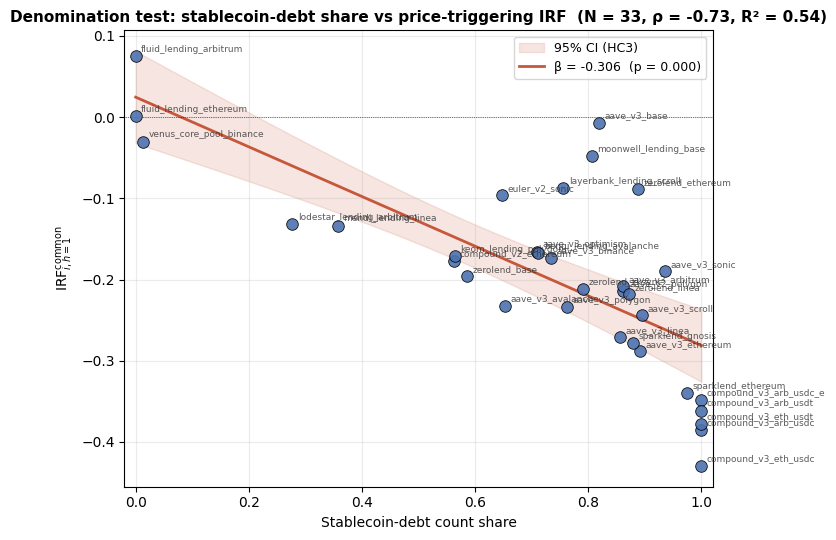

In [12]:
import glob
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from build_gold_panel_by_denomination import is_stablecoin

MIN_EVENTS = 200

events = pd.concat(
    [pd.read_parquet(p) for p in glob.glob(str(PROJECT_ROOT / 'data' / 'silver' / 'liquidations' / '*' / 'liquidations.parquet'))],
    ignore_index=True,
)
events['is_stable'] = events['debt_symbol'].apply(is_stablecoin)
denom_agg = events.groupby('csu').agg(
    n_events=('tx_hash', 'count'),
    stable_share=('is_stable', 'mean'),
).reset_index()
denom_agg = denom_agg[denom_agg['n_events'] >= MIN_EVENTS]

denom_panel = irf_h1_comm.merge(denom_agg, on='csu').merge(tvl_agg, on='csu', how='left')
denom_panel = denom_panel[denom_panel['tvl_supply_mean_usd'] > 0].copy()

print(f'N = {len(denom_panel)}  (min n_events = {MIN_EVENTS})')

# Bivariate regression
s = denom_panel.dropna(subset=['irf_h1_common', 'stable_share'])
X = sm.add_constant(s['stable_share'])
res_b = sm.OLS(s['irf_h1_common'], X).fit(cov_type='HC3')
print(f'\nBivariate OLS: irf_h1_common ~ const + stable_share')
print(f'  N = {int(res_b.nobs)}   R² = {res_b.rsquared:.3f}')
print(f'  const         = {res_b.params["const"]:+.4f}   SE = {res_b.bse["const"]:.4f}   t = {res_b.tvalues["const"]:+.2f}   p = {res_b.pvalues["const"]:.4f}')
print(f'  stable_share  = {res_b.params["stable_share"]:+.4f}   SE = {res_b.bse["stable_share"]:.4f}   t = {res_b.tvalues["stable_share"]:+.2f}   p = {res_b.pvalues["stable_share"]:.4f}')

# Single-panel scatter
fig, ax = plt.subplots(figsize=(8, 5.5))
x = denom_panel['stable_share'].values; y = denom_panel['irf_h1_common'].values
rho = np.corrcoef(x, y)[0, 1]
xs = np.linspace(0, 1, 100)
pred = res_b.get_prediction(sm.add_constant(xs)).summary_frame(alpha=0.05)
ax.fill_between(xs, pred['mean_ci_lower'], pred['mean_ci_upper'], color='#c7573b', alpha=0.15, label='95% CI (HC3)')
ax.plot(xs, pred['mean'], '-', color='#c7573b', lw=2.0,
         label=f'β = {res_b.params["stable_share"]:+.3f}  (p = {res_b.pvalues["stable_share"]:.3f})')
ax.scatter(x, y, s=70, color='#4c72b0', edgecolor='black', linewidth=0.6, alpha=0.9, zorder=3)
for _, r in denom_panel.iterrows():
    ax.annotate(r['csu'], xy=(r['stable_share'], r['irf_h1_common']), xytext=(4, 3),
                textcoords='offset points', fontsize=6.5, color='#333', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_xlabel('Stablecoin-debt count share')
ax.set_ylabel(r'$\mathrm{IRF}^{\mathrm{common}}_{i, h=1}$')
ax.set_title(f'Denomination test: stablecoin-debt share vs price-triggering IRF  (N = {len(denom_panel)}, ρ = {rho:+.2f}, R² = {res_b.rsquared:.2f})',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.25); ax.legend(loc='best', fontsize=9)
ax.set_xlim(-0.02, 1.02)
fig.tight_layout()
fig.savefig(SS_OUT_DIR / 'denomination_v2_scatter.png', dpi=140, bbox_inches='tight')
plt.show()

denom_panel.to_csv(SS_OUT_DIR / 'denomination_v2_panel.csv', index=False)
